# Food Spoilage Prediction – Machine Learning Project


### Research Question

> **Can machine learning predict whether a food product will spoil using product, storage, handling, demand and supply-chain information?**

### Target Variable

`was_spoiled`

- `0` = Unlikely to Spoil
- `1` = Likely to Spoil


# DATA COLLECTION

## 1.1 Import Pandas

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Load the Dataset

Dataset is from the Kaggle its a synthetic dataset. 


In [55]:
file_path = 'perishable_cleaned_balanced.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1.3 Check Dataset Size

In [56]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 38884
Number of columns: 42


## 1.4 View the First Rows

In [57]:
df.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,68208,BEV_MIL_895,Milk Alternatives,Beverages,STORE_044,Northeast,SUPPLIER_11,2024-11-15,2024-12-12,30,...,9.75,0,55,100.0,0.00,305.25,-305.25,0.0,6,1
1,10766,BEV_MIL_974,Milk Alternatives,Beverages,STORE_030,Southwest,SUPPLIER_17,2024-01-26,2024-02-09,14,...,2.52,129,56,30.3,325.08,57.68,134.53,41.4,9,1
2,52293,REA_SOU_940,Soups,Ready_to_Eat,STORE_045,Southwest,SUPPLIER_12,2024-12-23,2024-12-24,1,...,3.99,269,116,30.1,1073.31,982.52,-2187.64,-203.8,6,0
3,88623,DAI_BUT_775,Butter,Dairy,STORE_018,West,SUPPLIER_01,2024-09-07,2024-09-16,9,...,7.57,239,103,30.1,1809.23,473.80,236.03,13.0,7,0
4,79413,PHA_ANT_747,Antibiotics,Pharmaceuticals,STORE_005,Southeast,SUPPLIER_04,2024-02-03,2024-10-03,262,...,331.06,0,17,100.0,0.00,3259.07,-3259.07,0.0,9,0


## 1.5 View All Column Names

In [58]:
print(df.columns.tolist())

['record_id', 'product_id', 'product_name', 'category', 'store_id', 'region', 'supplier_id', 'transaction_date', 'expiration_date', 'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation', 'base_price', 'cost_price', 'initial_quantity', 'spoilage_sensitivity', 'day_of_week', 'is_weekend', 'month', 'daily_demand', 'demand_variability', 'temp_abuse_events', 'distribution_hours', 'handling_score', 'packaging_score', 'spoilage_risk', 'was_spoiled', 'quality_grade', 'days_until_expiry', 'markdown_applied', 'discount_pct', 'selling_price', 'units_sold', 'units_wasted', 'waste_pct', 'revenue', 'waste_cost', 'profit', 'profit_margin_pct', 'supplier_score', 'is_promoted']


## 1.6 Check Data Types

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38884 entries, 0 to 38883
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   38884 non-null  int64  
 1   product_id                  38884 non-null  object 
 2   product_name                38884 non-null  object 
 3   category                    38884 non-null  object 
 4   store_id                    38884 non-null  object 
 5   region                      38884 non-null  object 
 6   supplier_id                 38884 non-null  object 
 7   transaction_date            38884 non-null  object 
 8   expiration_date             38884 non-null  object 
 9   shelf_life_days             38884 non-null  int64  
 10  days_remaining_at_purchase  38884 non-null  int64  
 11  storage_temp                38884 non-null  float64
 12  temp_deviation              38884 non-null  float64
 13  base_price                  388

## 1.7 Check the Target Variable

Our target is `was_spoiled`.

This is a **binary classification** problem because there are two possible outcomes:

- `0` = Unlikely to Spoil
- `1` = Likely to Spoil


In [60]:
print(df['was_spoiled'].value_counts())

was_spoiled
0    19442
1    19442
Name: count, dtype: int64


## 1.8 Initial Feature Selection


### Main features

`category`
`region`
`shelf_life_days`
`days_remaining_at_purchase`
`storage_temp`
`temp_deviation`
`initial_quantity`
`spoilage_sensitivity`
`daily_demand`
`demand_variability`
`temp_abuse_events`
`distribution_hours`
`handling_score`
`packaging_score`
`supplier_score`

### Target

`was_spoiled`


# DATA CLEANING & EDA


## 2.1 Check Missing Values

In [61]:
missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Series([], dtype: int64)

Total missing values: 0


## 2.2 Check Duplicate Rows

In [62]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 2.3 Remove Exact Duplicates

In [63]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (38884, 42)


## 2.4 Basic Statistics

In [64]:
df.describe()

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,...,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000
mean,50084.461604,66.815863,55.713250,3.124300,1.638774,37.251379,20.533892,254.807582,0.692240,3.009464,...,35.014886,187.600761,67.206820,28.383248,5545.505140,1923.052482,337.563476,6.765230,8.207077,0.149316
std,28883.504480,140.233850,117.639708,9.375791,1.224085,88.196659,49.375107,141.654210,0.214487,1.996799,...,85.911597,128.526562,77.451229,26.554576,18029.019243,8340.444787,10373.944923,48.133105,1.399503,0.356404
min,5.000000,1.000000,0.000000,-26.900000,0.000000,1.010000,0.410000,10.000000,0.300000,0.000000,...,0.340000,0.000000,0.000000,0.000000,0.000000,0.000000,-166388.160000,-1490.200000,6.000000,0.000000
25%,25140.500000,5.000000,4.000000,1.100000,0.700000,6.350000,3.410000,133.000000,0.500000,1.000000,...,5.320000,79.000000,0.000000,0.000000,513.070000,0.000000,-95.242500,0.000000,7.000000,0.000000
50%,49988.500000,9.000000,7.000000,3.900000,1.400000,10.400000,5.670000,254.000000,0.750000,3.000000,...,8.865000,179.000000,48.000000,30.100000,1359.705000,215.635000,166.940000,16.800000,9.000000,0.000000
75%,75087.500000,24.000000,20.000000,6.600000,2.400000,17.290000,9.700000,377.000000,0.900000,5.000000,...,15.690000,283.000000,107.000000,31.200000,2975.595000,664.370000,735.900000,35.700000,9.000000,0.000000
max,100000.000000,730.000000,720.000000,27.200000,8.900000,499.800000,346.060000,500.000000,0.950000,6.000000,...,499.800000,500.000000,500.000000,100.000000,236062.400000,166388.160000,119976.480000,60.100000,10.000000,1.000000


In [65]:
# Numerical columns to check for outliers
outlier_columns = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'daily_demand',
    'demand_variability',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score'
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': column,
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier Percentage': round(
            len(outliers) / len(df) * 100, 2
        )
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,shelf_life_days,-23.50,52.50,7633,19.63
1,days_remaining_at_purchase,-20.00,44.00,7610,19.57
2,storage_temp,-7.15,14.85,7475,19.22
3,temp_deviation,-1.85,4.95,566,1.46
4,initial_quantity,-233.00,743.00,0,0.00
5,daily_demand,-115.50,208.50,2516,6.47
6,demand_variability,-0.10,0.70,0,0.00
7,distribution_hours,-28.90,106.30,0,0.00
8,handling_score,-1.00,15.00,0,0.00
9,packaging_score,1.50,13.50,0,0.00


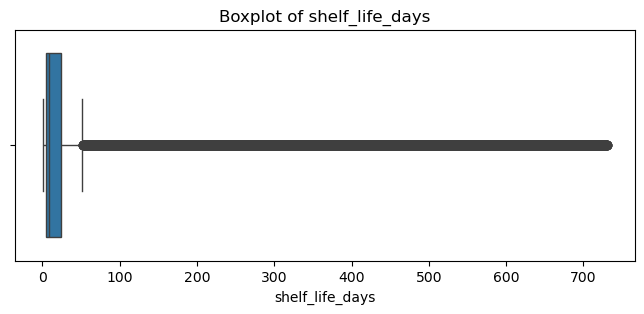

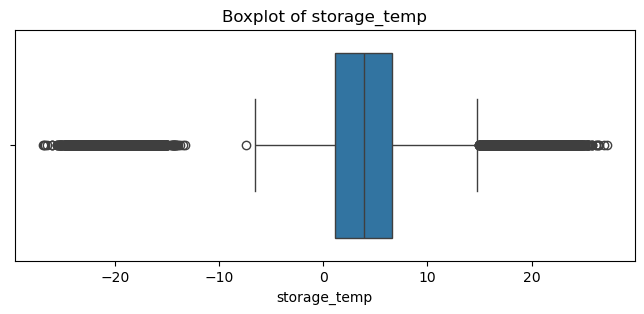

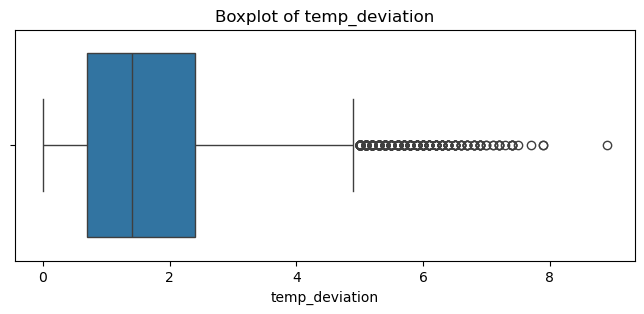

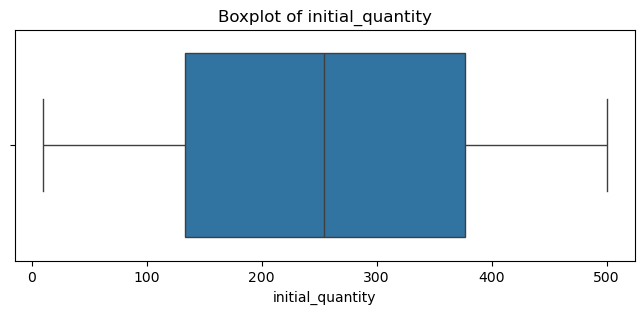

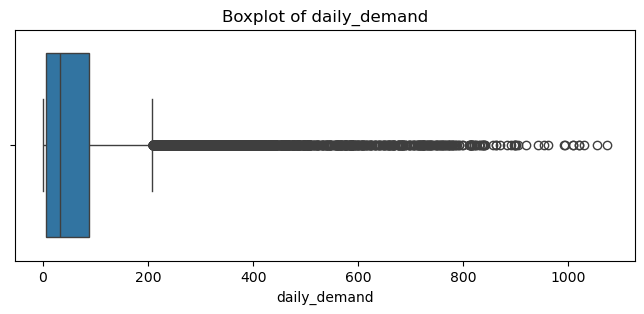

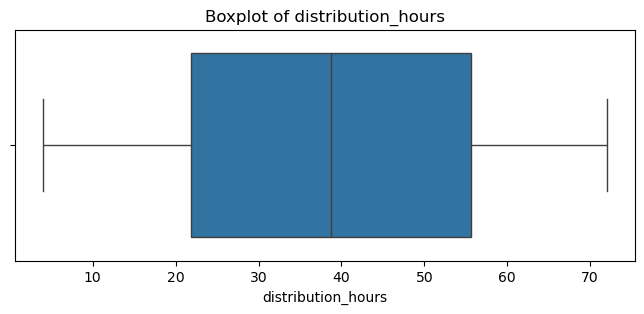

In [66]:
# Boxplots for selected numerical features
boxplot_columns = [
    'shelf_life_days',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'daily_demand',
    'distribution_hours'
]

for column in boxplot_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

## 2.5 Check the Target Distribution

was_spoiled
0    19442
1    19442
Name: count, dtype: int64


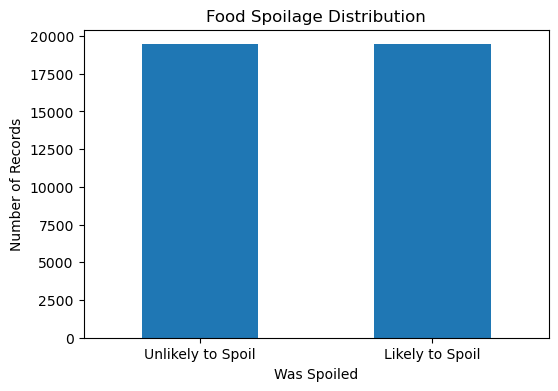

In [67]:
target_counts = df['was_spoiled'].value_counts()

print(target_counts)

target_counts.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Food Spoilage Distribution')
plt.xlabel('Was Spoiled')
plt.ylabel('Number of Records')
plt.xticks([0, 1], ['Unlikely to Spoil', 'Likely to Spoil'], rotation=0)
plt.show()

## 2.6 Target Percentages

In [68]:
target_percent = df['was_spoiled'].value_counts(normalize=True) * 100

print(target_percent)

was_spoiled
0    50.0
1    50.0
Name: proportion, dtype: float64


## 2.7 Explore Storage Temperature

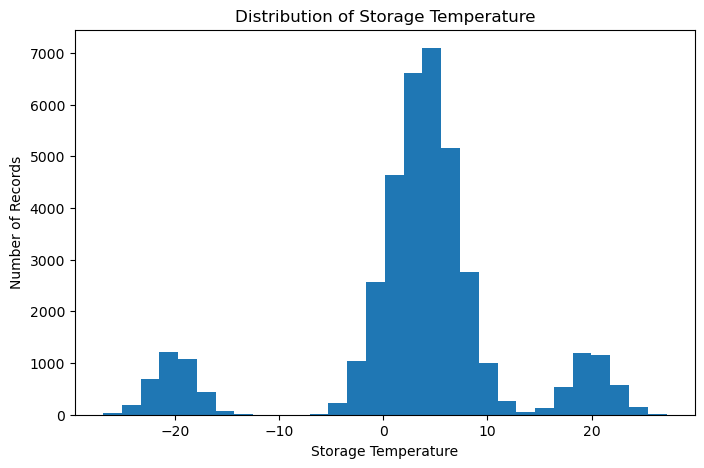

In [69]:
plt.figure(figsize=(8, 5))

plt.hist(df['storage_temp'].dropna(), bins=30)

plt.title('Distribution of Storage Temperature')
plt.xlabel('Storage Temperature')
plt.ylabel('Number of Records')

plt.show()

## 2.8 Explore Shelf Life

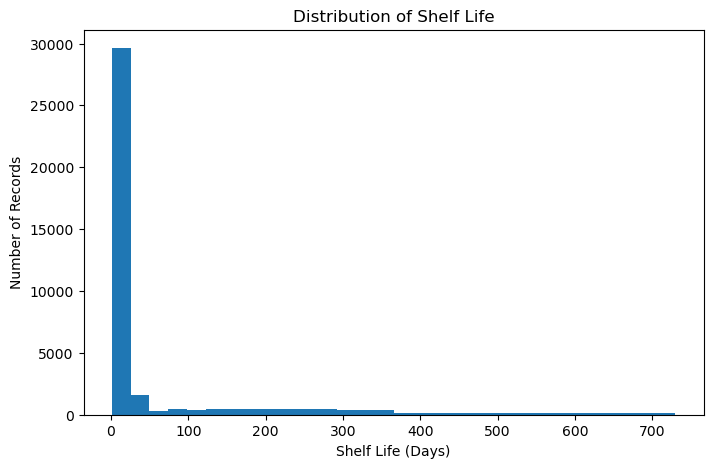

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(df['shelf_life_days'].dropna(), bins=30)

plt.title('Distribution of Shelf Life')
plt.xlabel('Shelf Life (Days)')
plt.ylabel('Number of Records')

plt.show()

## 2.9 Spoilage by Food Category

In [71]:
# Calculate spoilage rate and sample size for each category
category_summary = df.groupby('category')['was_spoiled'].agg(
    spoilage_rate='mean',
    sample_size='count'
)

# Convert spoilage rate to percentage
category_summary['spoilage_rate'] *= 100

# Calculate difference from the overall 50% base rate
category_summary['difference_from_50'] = (
    category_summary['spoilage_rate'] - 50
)

# Sort categories from highest to lowest spoilage rate
category_summary = category_summary.sort_values(
    'spoilage_rate',
    ascending=False
)

print(category_summary)

                 spoilage_rate  sample_size  difference_from_50
category                                                       
Ready_to_Eat         54.354207         4088            4.354207
Meat                 52.491281         4014            2.491281
Pharmaceuticals      51.766741         4047            1.766741
Seafood              51.245020         4016            1.245020
Deli                 50.103306         3872            0.103306
Bakery               48.803191         3760           -1.196809
Produce              48.797700         3826           -1.202300
Dairy                48.731227         3862           -1.268773
Beverages            47.768100         3674           -2.231900
Frozen_Meals         45.127517         3725           -4.872483


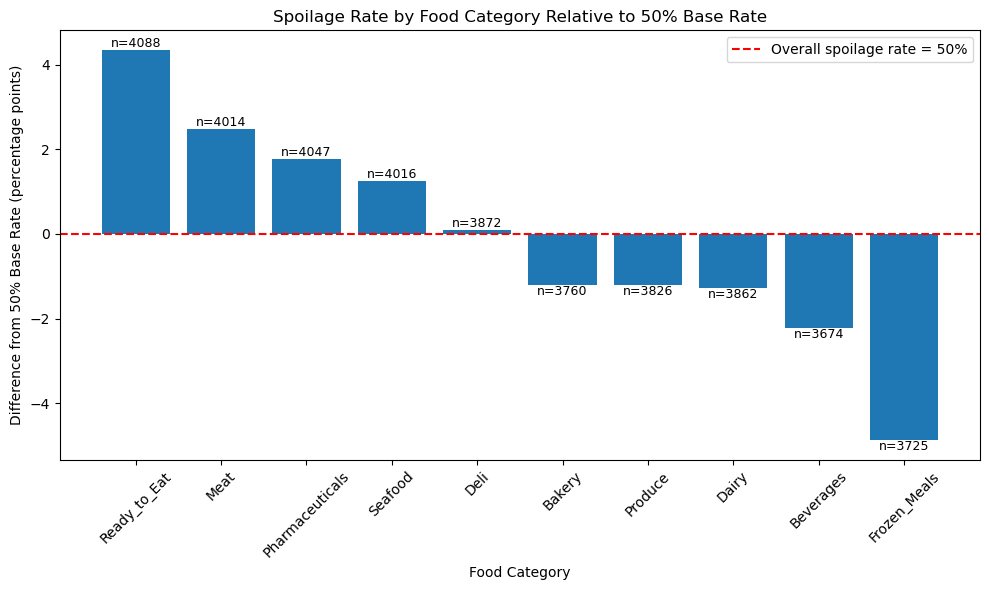

In [72]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_summary.index,
    category_summary['difference_from_50']
)

# Zero now represents the overall 50% spoilage rate
plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    label='Overall spoilage rate = 50%'
)

# Add sample size above or below each bar
for bar, sample_size in zip(
    bars,
    category_summary['sample_size']
):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'n={sample_size}',
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=9
    )

plt.title('Spoilage Rate by Food Category Relative to 50% Base Rate')
plt.xlabel('Food Category')
plt.ylabel('Difference from 50% Base Rate (percentage points)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
category_spread = (
    category_summary['spoilage_rate'].max()
    - category_summary['spoilage_rate'].min()
)

print(
    "Spread between highest and lowest category:",
    round(category_spread, 2),
    "percentage points"
)

Spread between highest and lowest category: 9.23 percentage points


## 2.10 Simple Correlation Check


In [74]:
numeric_columns = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score',
    'was_spoiled'
]

correlation = df[numeric_columns].corr()

correlation['was_spoiled'].sort_values(ascending=False)

was_spoiled                   1.000000
temp_deviation                0.051817
spoilage_sensitivity          0.045522
temp_abuse_events             0.033415
distribution_hours            0.029005
daily_demand                  0.028827
storage_temp                  0.018018
supplier_score                0.006395
demand_variability            0.004955
shelf_life_days              -0.002007
days_remaining_at_purchase   -0.003910
initial_quantity             -0.005853
handling_score               -0.075220
packaging_score              -0.110950
Name: was_spoiled, dtype: float64

# FEATURE ENGINEERING

## 3.1 Select the Final Features

In [75]:
print("Statistical Summary")
df[numeric_columns].describe().T

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
shelf_life_days,38884.0,66.815863,140.233850,1.0,5.0,9.00,24.0,730.00
days_remaining_at_purchase,38884.0,55.713250,117.639708,0.0,4.0,7.00,20.0,720.00
storage_temp,38884.0,3.124300,9.375791,-26.9,1.1,3.90,6.6,27.20
temp_deviation,38884.0,1.638774,1.224085,0.0,0.7,1.40,2.4,8.90
initial_quantity,38884.0,254.807582,141.654210,10.0,133.0,254.00,377.0,500.00
spoilage_sensitivity,38884.0,0.692240,0.214487,0.3,0.5,0.75,0.9,0.95
daily_demand,38884.0,66.030347,95.982872,0.0,6.0,33.00,87.0,1073.00
demand_variability,38884.0,0.300925,0.115379,0.1,0.2,0.30,0.4,0.50
temp_abuse_events,38884.0,0.827615,1.099826,0.0,0.0,0.00,1.0,8.00
distribution_hours,38884.0,38.600808,19.602082,4.0,21.8,38.80,55.6,72.00


In [76]:
corr = df[numeric_columns].corr()

In [77]:
features = [
    'category',
    'region',
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score'
]

target = 'was_spoiled'

X = df[features].copy()
y = df[target].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 15
X shape: (38884, 15)
y shape: (38884,)


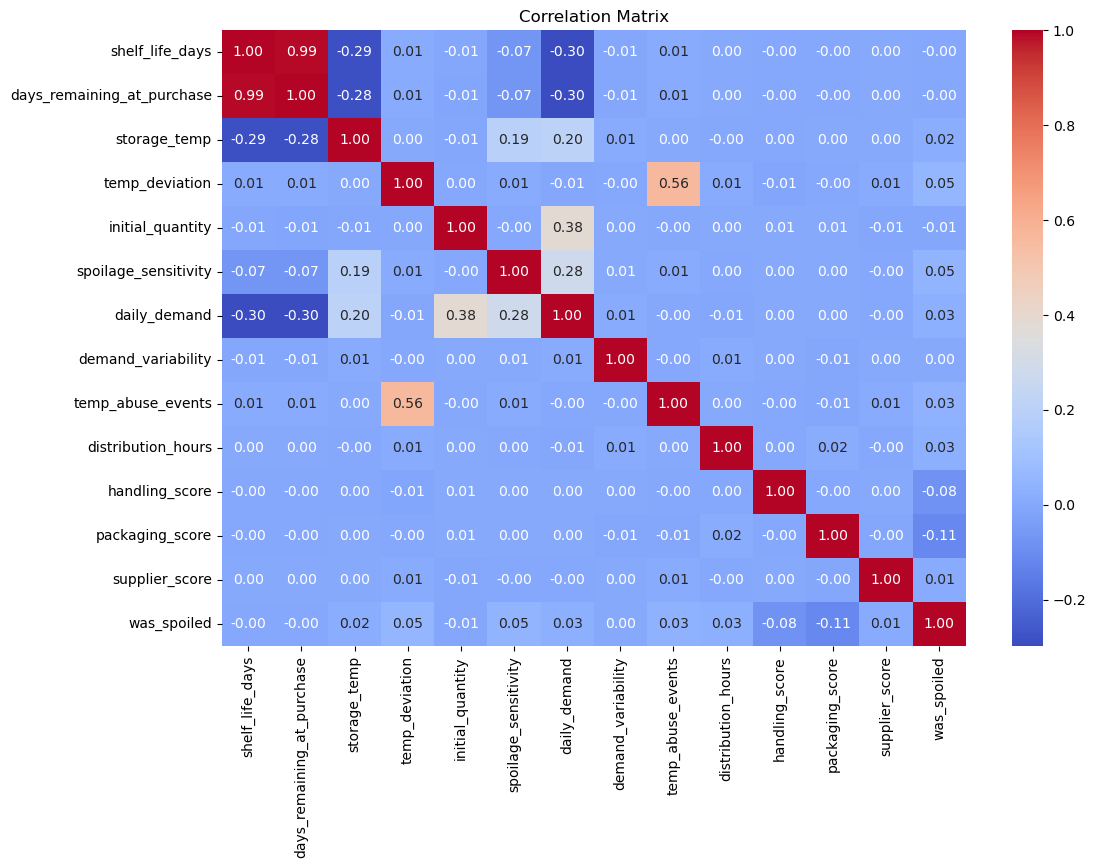

In [78]:
import seaborn as sns
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

## 3.2 Create a Simple Temperature Risk Feature


In [79]:
X['temperature_problem'] = (
    X['temp_deviation'] >= 2
).astype(int)

print(X[['temp_deviation', 'temperature_problem']].head())

   temp_deviation  temperature_problem
0             1.0                    0
1             1.9                    0
2             2.0                    1
3             2.3                    1
4             0.3                    0


## 3.3 Create a Simple Demand Pressure Feature


In [80]:
X['inventory_days_estimate'] = (
    X['initial_quantity'] /
    X['daily_demand'].replace(0, np.nan)
)
 
# When daily_demand is 0, nothing is selling — the stock will sit until
# it expires, so cap the estimate at the product's shelf life instead of
# encoding it as "sells out instantly" (0 days).
X['inventory_days_estimate'] = X['inventory_days_estimate'].fillna(X['shelf_life_days'])
 
print(X[['initial_quantity', 'daily_demand', 'inventory_days_estimate']].head())

   initial_quantity  daily_demand  inventory_days_estimate
0                55             0                30.000000
1               185            20                 9.250000
2               385           522                 0.737548
3               342            62                 5.516129
4                17             0               262.000000


## 3.4 Update the Numerical Feature List


In [81]:
categorical_features = [
    'category',
    'region'
]

numerical_features = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score',
    'temperature_problem',
    'inventory_days_estimate'
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['category', 'region']
Number of numerical features: 15


## 3.5 Check the Final Dataset

In [82]:
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

X.head()

Final X shape: (38884, 17)
Final y shape: (38884,)


,category,region,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,initial_quantity,spoilage_sensitivity,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,supplier_score,temperature_problem,inventory_days_estimate
0,Beverages,Northeast,30,27,4.0,1.0,55,0.40,0,0.48,1,71.7,9,6,6,0,30.000000
1,Beverages,Southwest,14,14,6.9,1.9,185,0.40,20,0.15,0,13.2,6,7,9,0,9.250000
2,Ready_to_Eat,Southwest,1,1,6.0,2.0,385,0.90,522,0.31,1,63.1,4,5,6,1,0.737548
3,Dairy,West,9,9,6.3,2.3,342,0.70,62,0.16,0,27.9,10,6,7,1,5.516129
4,Pharmaceuticals,Southeast,262,243,5.3,0.3,17,0.85,0,0.35,0,24.2,4,8,9,0,262.000000


# MODELING


## 4.1 Import Machine Learning Libraries

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 4.2 Split the Data


In [84]:
from sklearn.model_selection import train_test_split

# 60% training and 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Divide temporary data equally:
# 20% validation and 20% test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_validation.shape, y_validation.shape)
print("Test data:", X_test.shape, y_test.shape)

print("\nTraining percentage:", len(X_train) / len(X) * 100)
print("Validation percentage:", len(X_validation) / len(X) * 100)
print("Test percentage:", len(X_test) / len(X) * 100)

Training data: (23330, 17) (23330,)
Validation data: (7777, 17) (7777,)
Test data: (7777, 17) (7777,)

Training percentage: 59.99897129924905
Validation percentage: 20.000514350375475
Test percentage: 20.000514350375475


## 4.3 Preprocess the Features


In [85]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


## Baseline Model – DummyClassifier

In [86]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent'))
    ]
)

baseline.fit(X_train, y_train)

baseline_validation_predictions = baseline.predict(
    X_validation
)

print("DummyClassifier trained successfully.")

DummyClassifier trained successfully.


In [87]:
baseline_validation_accuracy = accuracy_score(
    y_validation,
    baseline_validation_predictions
)

print(
    "DummyClassifier validation accuracy:",
    round(baseline_validation_accuracy, 4)
)

print(
    "DummyClassifier validation accuracy:",
    round(baseline_validation_accuracy * 100, 2),
    "%"
)

DummyClassifier validation accuracy: 0.4999
DummyClassifier validation accuracy: 49.99 %


## 4.4 Model 1 – Logistic Regression


In [88]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 4.5 Make Logistic Regression Predictions

In [89]:
logistic_validation_predictions = logistic_model.predict(
    X_validation
)

print("Logistic Regression validation predictions completed.")

Logistic Regression validation predictions completed.


## 4.6 Model 2 – Random Forest


In [90]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 4.7 Make Random Forest Predictions

In [91]:
rf_validation_predictions = random_forest_model.predict(
    X_validation
)

print("Random Forest validation predictions completed.")

Random Forest validation predictions completed.


# EVALUATION


## 5.1 Import Evaluation Metrics

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 5.2 Evaluate Logistic Regression

In [93]:
logistic_validation_accuracy = accuracy_score(
    y_validation,
    logistic_validation_predictions
)

logistic_validation_precision = precision_score(
    y_validation,
    logistic_validation_predictions
)

logistic_validation_recall = recall_score(
    y_validation,
    logistic_validation_predictions
)

logistic_validation_f1 = f1_score(
    y_validation,
    logistic_validation_predictions
)

print("Logistic Regression Validation Results")
print("Accuracy :", logistic_validation_accuracy)
print("Precision:", logistic_validation_precision)
print("Recall   :", logistic_validation_recall)
print("F1 Score :", logistic_validation_f1)

Logistic Regression Validation Results
Accuracy : 0.568085379966568
Precision: 0.5673272357723578
Recall   : 0.5741835947544356
F1 Score : 0.5707348242811502


## 5.3 Evaluate Random Forest

In [94]:
rf_validation_accuracy = accuracy_score(
    y_validation,
    rf_validation_predictions
)

rf_validation_precision = precision_score(
    y_validation,
    rf_validation_predictions
)

rf_validation_recall = recall_score(
    y_validation,
    rf_validation_predictions
)

rf_validation_f1 = f1_score(
    y_validation,
    rf_validation_predictions
)

print("Random Forest Validation Results")
print("Accuracy :", rf_validation_accuracy)
print("Precision:", rf_validation_precision)
print("Recall   :", rf_validation_recall)
print("F1 Score :", rf_validation_f1)

Random Forest Validation Results
Accuracy : 0.5446830397325447
Precision: 0.544799176107106
Recall   : 0.544098740035999
F1 Score : 0.5444487327930014


## 5.4 Compare  Models

This table makes it easy to identify the better model.

In [95]:
validation_results = pd.DataFrame({
    'Model': [
        'DummyClassifier',
        'Logistic Regression',
        'Original Random Forest'
    ],
    'Accuracy': [
        baseline_validation_accuracy,
        logistic_validation_accuracy,
        rf_validation_accuracy
    ],
    'Precision': [
        np.nan,
        logistic_validation_precision,
        rf_validation_precision
    ],
    'Recall': [
        np.nan,
        logistic_validation_recall,
        rf_validation_recall
    ],
    'F1 Score': [
        np.nan,
        logistic_validation_f1,
        rf_validation_f1
    ]
})

validation_results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.568085,0.567327,0.574184,0.570735
2,Original Random Forest,0.544683,0.544799,0.544099,0.544449
0,DummyClassifier,0.499936,NaN,NaN,NaN


# Random Forest tuning

## Random Forest Tuning Using the Validation Set

In [96]:
rf_tuning_results = []

parameter_options = [
    {
        'n_estimators': 100,
        'max_depth': 5,
        'min_samples_split': 2
    },
    {
        'n_estimators': 200,
        'max_depth': 8,
        'min_samples_split': 2
    },
    {
        'n_estimators': 200,
        'max_depth': 10,
        'min_samples_split': 5
    },
    {
        'n_estimators': 300,
        'max_depth': None,
        'min_samples_split': 5
    }
]

for parameters in parameter_options:

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            (
                'model',
                RandomForestClassifier(
                    n_estimators=parameters['n_estimators'],
                    max_depth=parameters['max_depth'],
                    min_samples_split=parameters[
                        'min_samples_split'
                    ],
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(X_train, y_train)

    validation_predictions = model.predict(
        X_validation
    )

    validation_accuracy = accuracy_score(
        y_validation,
        validation_predictions
    )

    validation_f1 = f1_score(
        y_validation,
        validation_predictions
    )

    rf_tuning_results.append({
        'n_estimators':
            parameters['n_estimators'],
        'max_depth':
            parameters['max_depth'],
        'min_samples_split':
            parameters['min_samples_split'],
        'Validation Accuracy':
            validation_accuracy,
        'Validation F1':
            validation_f1,
        'Model':
            model
    })

# Create a results table:

In [97]:
rf_tuning_table = pd.DataFrame([
    {
        'n_estimators':
            result['n_estimators'],
        'max_depth':
            result['max_depth'],
        'min_samples_split':
            result['min_samples_split'],
        'Validation Accuracy':
            result['Validation Accuracy'],
        'Validation F1':
            result['Validation F1']
    }
    for result in rf_tuning_results
])

rf_tuning_table.sort_values(
    by='Validation Accuracy',
    ascending=False
)

,n_estimators,max_depth,min_samples_split,Validation Accuracy,Validation F1
1,200,8.0,2,0.567185,0.571974
0,100,5.0,2,0.565514,0.570484
2,200,10.0,5,0.564871,0.569794
3,300,NaN,5,0.552398,0.556391


# Selecting tuned random forest

In [98]:
best_rf_result = max(
    rf_tuning_results,
    key=lambda result:
        result['Validation Accuracy']
)

best_random_forest_model = best_rf_result['Model']

print("Best Random Forest parameters:")
print(
    "n_estimators:",
    best_rf_result['n_estimators']
)
print(
    "max_depth:",
    best_rf_result['max_depth']
)
print(
    "min_samples_split:",
    best_rf_result['min_samples_split']
)
print(
    "Validation accuracy:",
    best_rf_result['Validation Accuracy']
)

Best Random Forest parameters:
n_estimators: 200
max_depth: 8
min_samples_split: 2
Validation accuracy: 0.5671852899575672


# Compare Logistic Regression with the tuned Random Forest

In [99]:
best_rf_validation_predictions = (
    best_random_forest_model.predict(
        X_validation
    )
)

best_rf_validation_accuracy = accuracy_score(
    y_validation,
    best_rf_validation_predictions
)

best_rf_validation_f1 = f1_score(
    y_validation,
    best_rf_validation_predictions
)

In [100]:
final_validation_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Random Forest'
    ],
    'Validation Accuracy': [
        logistic_validation_accuracy,
        best_rf_validation_accuracy
    ],
    'Validation F1': [
        logistic_validation_f1,
        best_rf_validation_f1
    ]
})

final_validation_comparison.sort_values(
    by='Validation Accuracy',
    ascending=False
)

,Model,Validation Accuracy,Validation F1
0,Logistic Regression,0.568085,0.570735
1,Tuned Random Forest,0.567185,0.571974


In [101]:
if (
    logistic_validation_accuracy
    >= best_rf_validation_accuracy
):
    selected_model = logistic_model
    selected_model_name = (
        'Logistic Regression'
    )
else:
    selected_model = best_random_forest_model
    selected_model_name = (
        'Tuned Random Forest'
    )

print("Selected model:", selected_model_name)

Selected model: Logistic Regression


# Using the test set

In [102]:
test_predictions = selected_model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions
)

test_recall = recall_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions
)

print("Final Test Results")
print("Selected model:", selected_model_name)
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1 Score :", test_f1)

Final Test Results
Selected model: Logistic Regression
Accuracy : 0.5685997171145686
Precision: 0.5674512781574285
Recall   : 0.5766460905349794
F1 Score : 0.5720117361908407


## 5.5 Final Test Confusion Matrix



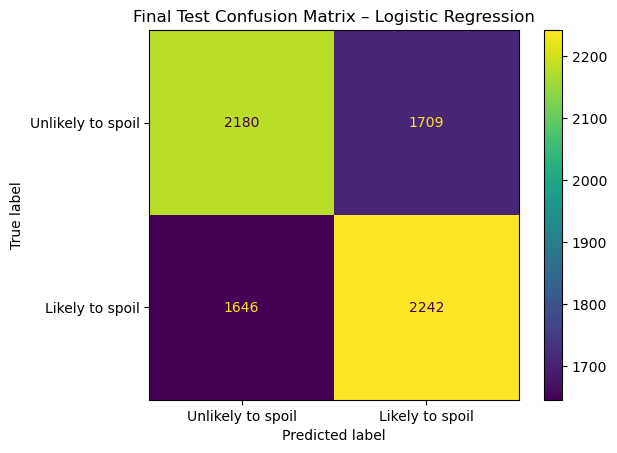

In [103]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Unlikely to spoil',
        'Likely to spoil'
    ]
)

disp.plot()

plt.title(
    f'Final Test Confusion Matrix – {selected_model_name}'
)

plt.show()

## 5.7 Permutation Importance on the Validation Set

In [104]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    best_random_forest_model,
    X_validation,
    y_validation,
    scoring='accuracy',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [105]:
permutation_importance_df = pd.DataFrame({
    'Feature': X_validation.columns,
    'Importance Mean':
        permutation_result.importances_mean,
    'Importance Standard Deviation':
        permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        by='Importance Mean',
        ascending=False
    )
)

permutation_importance_df.head(15)

,Feature,Importance Mean,Importance Standard Deviation
13,packaging_score,0.042034,0.004302
12,handling_score,0.011984,0.003742
5,temp_deviation,0.003896,0.001556
7,spoilage_sensitivity,0.001504,0.002805
16,inventory_days_estimate,0.001427,0.001966
8,daily_demand,0.001376,0.001989
10,temp_abuse_events,0.001222,0.001135
11,distribution_hours,0.000733,0.001478
14,supplier_score,0.000656,0.000970
6,initial_quantity,0.000553,0.000756


## Plot Permutation Importance

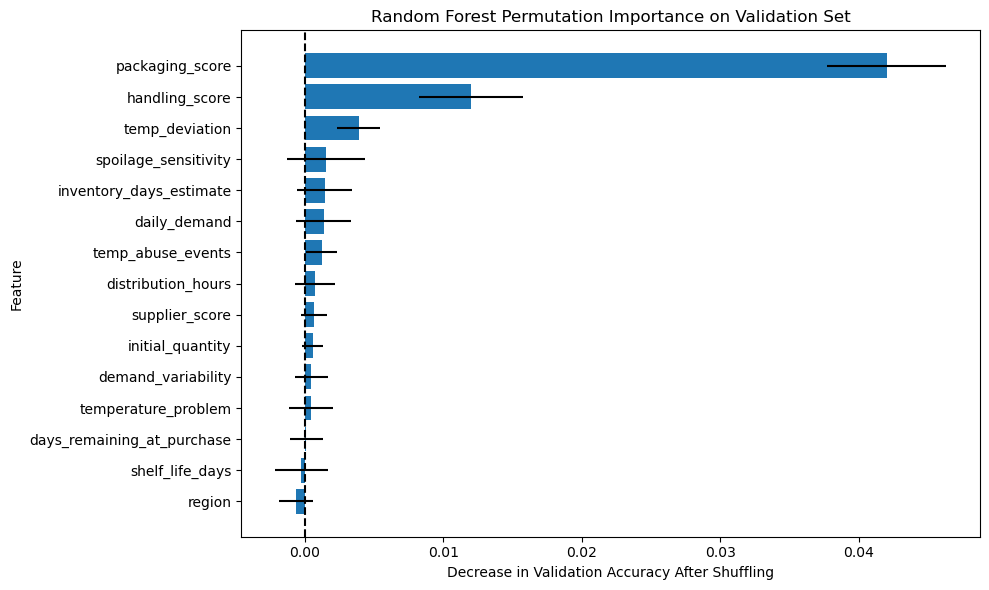

In [106]:
top_features = permutation_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance Mean'][::-1],
    xerr=top_features[
        'Importance Standard Deviation'
    ][::-1]
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Random Forest Permutation Importance on Validation Set'
)

plt.xlabel(
    'Decrease in Validation Accuracy After Shuffling'
)

plt.ylabel('Feature')

plt.tight_layout()
plt.show()

**project conclusion:**


The dataset was balanced, so the chance-level baseline was approximately 50%. Logistic Regression achieved the highest validation accuracy at 56.81%, while the tuned Random Forest achieved 56.72%. Logistic Regression was therefore selected and achieved 56.86% accuracy on the untouched test set. The model performed slightly better than chance, but its predictive ability remained limited. Permutation importance showed that packaging score and handling score were the most useful Random Forest features, while most other features provided little stable improvement.



Important limitations

    The dataset is synthetic.
    The final accuracy is only slightly above chance.
    The category spread is only around 9.23 percentage points.
    Most feature correlations are weak.
    Feature importance does not prove causation.
    More informative features may be required.

The main limitation is that the available features do not strongly separate spoiled and non-spoiled products. Future work could include more detailed time-series temperature information, humidity, product-specific storage conditions and real-world sensor data.